# Signed Features: What Happens When Features Can Be Negative?

## Motivation

The Toy Models of Superposition paper (Elhage et al.) assumes features are sampled from Uniform[0,1] with extra probability mass at 0. This is a **simplifying assumption**, not a fundamental requirement. In practice, features in LLMs can be signed — e.g., sentiment direction, grammatical number, or any feature where the absence of a concept is distinct from its negation.

**Key questions:**
1. How does superposition geometry change when features are signed (Uniform[-1,1])?
2. The final ReLU in our decoder enforces non-negative output — what architectural changes are needed?
3. Does the nonlinear gain (encoder nonlinearity benefit) change with signed features?
4. Do antipodal pairs emerge more or less readily?

## Literature context
- Elhage et al. chose non-negative features for analytical tractability and because ReLU naturally filters negative interference
- With non-negative features + ReLU, models use **thresholding** to cancel cross-talk between superposed features
- With signed features, the model may need to learn **absolute value circuits** (paired ReLU gates) to handle negative values
- Antipodal pairs (feature directions that are negatives of each other) appear even with non-negative inputs — signed inputs may change this geometry
- "From Data Statistics to Feature Geometry" (2026) shows correlated/signed features produce qualitatively different superposition

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from core import (
    Autoencoder, device, generate_sparse_data,
    measure_encoding_linearity, compute_feature_geometry,
    compute_jacobian_stats, get_feature_importance
)

print(f"Device: {device}")

Device: cpu


## 1. Data generation: signed sparse features

We define sparse signed features: each feature is active with probability (1-S), and when active, drawn from Uniform[-1, 1] instead of Uniform[0, 1].

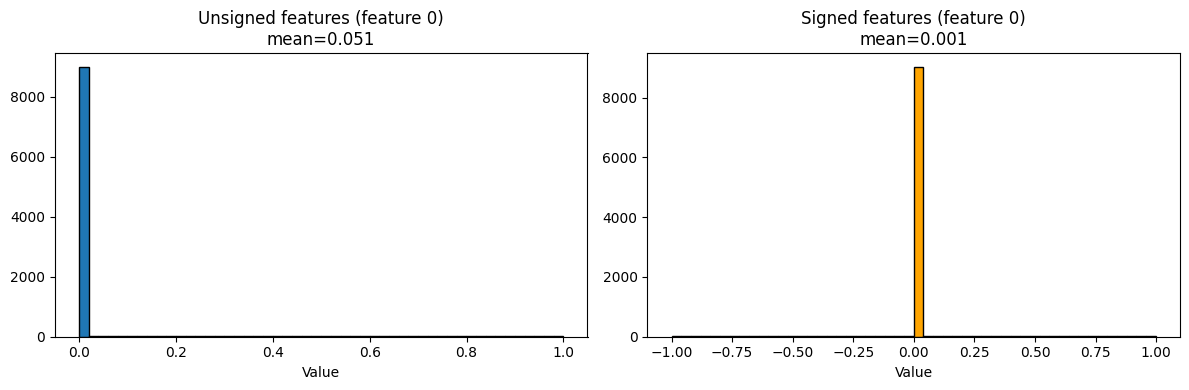

Unsigned: min=0.000, max=1.000, frac_zero=0.899
Signed:   min=-1.000, max=1.000, frac_zero=0.901


In [2]:
def generate_signed_sparse_data(n_samples: int, n_features: int, S: float = 0.95) -> torch.Tensor:
    """Sparse data with signed features: active features ~ Uniform[-1, 1]."""
    mask = (torch.rand(n_samples, n_features) > S).float()
    values = 2 * torch.rand(n_samples, n_features) - 1  # Uniform[-1, 1]
    return (mask * values).to(device)

# Quick sanity check
x_unsigned = generate_sparse_data(10000, 20, S=0.9)
x_signed = generate_signed_sparse_data(10000, 20, S=0.9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_unsigned[:, 0].cpu().numpy(), bins=50, edgecolor='black')
axes[0].set_title(f'Unsigned features (feature 0)\nmean={x_unsigned[:, 0].mean():.3f}')
axes[0].set_xlabel('Value')
axes[1].hist(x_signed[:, 0].cpu().numpy(), bins=50, edgecolor='black', color='orange')
axes[1].set_title(f'Signed features (feature 0)\nmean={x_signed[:, 0].mean():.3f}')
axes[1].set_xlabel('Value')
plt.tight_layout()
plt.show()

print(f"Unsigned: min={x_unsigned.min():.3f}, max={x_unsigned.max():.3f}, frac_zero={( x_unsigned == 0).float().mean():.3f}")
print(f"Signed:   min={x_signed.min():.3f}, max={x_signed.max():.3f}, frac_zero={(x_signed == 0).float().mean():.3f}")

## 2. Architecture modification: removing the final ReLU

The current `Autoencoder` has a final ReLU in the decoder, which clamps output to be non-negative. For signed features, we need to either:
- (a) Remove the final ReLU entirely
- (b) Keep internal ReLUs but allow the final output to be unconstrained

We create a `SignedAutoencoder` that does (b): same architecture but no final activation.

In [3]:
class SignedAutoencoder(nn.Module):
    """
    Autoencoder for signed features. Same as Autoencoder but:
    - No final ReLU on decoder output (allows negative reconstruction)
    - For l=1 tied weights: no ReLU on output
    """
    def __init__(self, n: int, m: int, l: int = 1, tied_weights: bool = True):
        super().__init__()
        self.n = n
        self.m = m
        self.l = l
        self.tied_weights = tied_weights and (l == 1)

        if self.tied_weights:
            self.encoder = nn.Linear(n, m, bias=False)
            self.decoder_bias = nn.Parameter(torch.zeros(n))
        else:
            # Encoder: same as original (no biases in hidden layers for homogeneity analysis)
            encoder_layers = []
            for i in range(l - 1):
                encoder_layers.append(nn.Linear(n, n))
                encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Linear(n, m))
            self.encoder = nn.Sequential(*encoder_layers)

            # Decoder: same as original BUT no final ReLU
            decoder_layers = []
            decoder_layers.append(nn.Linear(m, n))
            for i in range(l - 1):
                decoder_layers.append(nn.ReLU())
                decoder_layers.append(nn.Linear(n, n))
            # NO final activation — output can be negative
            self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        if self.tied_weights:
            return z @ self.encoder.weight + self.decoder_bias  # No ReLU
        else:
            return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

print("SignedAutoencoder l=1:", SignedAutoencoder(10, 5, l=1))
print("\nSignedAutoencoder l=2:", SignedAutoencoder(10, 5, l=2))

SignedAutoencoder l=1: SignedAutoencoder(
  (encoder): Linear(in_features=10, out_features=5, bias=False)
)

SignedAutoencoder l=2: SignedAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=5, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)


## 3. Training infrastructure for signed features

In [4]:
def train_signed_autoencoder(
    model, n_steps=10000, batch_size=1024, S=0.95,
    lr=1e-3, weight_decay=1e-2, signed=True,
    importance=None, verbose=True
):
    """Train autoencoder on either signed or unsigned data."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    gen_fn = generate_signed_sparse_data if signed else generate_sparse_data
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = gen_fn(batch_size, model.n, S)
        optimizer.zero_grad()
        x_recon, z = model(x)
        
        if importance is not None:
            loss = (importance * (x - x_recon) ** 2).mean()
        else:
            loss = nn.functional.mse_loss(x_recon, x)
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if verbose and step % 2000 == 0:
            iterator.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return losses


def measure_signed_linearity(model, n_samples=2000, S=0.95, signed=True):
    """Measure encoding linearity, generating signed or unsigned data."""
    model.eval()
    gen_fn = generate_signed_sparse_data if signed else generate_sparse_data
    
    with torch.no_grad():
        x = gen_fn(n_samples, model.n, S)
        z = model.encode(x)
        
        # Fit best linear encoder
        x_with_bias = torch.cat([x, torch.ones(n_samples, 1, device=device)], dim=1)
        W_linear = torch.linalg.lstsq(x_with_bias, z).solution
        z_linear = x_with_bias @ W_linear
        
        z_var = z.var(dim=0).sum()
        residual_var = (z - z_linear).var(dim=0).sum()
        linearity_score = 1 - (residual_var / z_var).item()
        
        x_recon_full, _ = model(x)
        x_recon_linear = model.decode(z_linear)
        
        mse_full = nn.functional.mse_loss(x_recon_full, x).item()
        mse_linear = nn.functional.mse_loss(x_recon_linear, x).item()
    
    return {
        'linearity_score': linearity_score,
        'mse_full': mse_full,
        'mse_linear': mse_linear,
        'nonlinear_gain': (mse_linear - mse_full) / (mse_linear + 1e-8)
    }

## 4. Experiment 1: Signed vs Unsigned, l=1 (linear encoder, tied weights)

Start with the simplest case matching the Toy Models paper setup. Compare:
- **Unsigned + ReLU decoder** (original setup)
- **Signed + no-ReLU decoder** (our new setup)
- **Signed + ReLU decoder** (mismatched — what goes wrong?)

In [5]:
# Parameters matching toy models paper
n, m = 20, 5
S = 0.95
n_steps = 15000
n_seeds = 20

configs = [
    ('Unsigned + ReLU (original)', False, Autoencoder, 1),
    ('Signed + No ReLU', True, SignedAutoencoder, 1),
    ('Signed + ReLU (mismatched)', True, Autoencoder, 1),
]

results_l1 = {}

for name, signed, ModelClass, l in configs:
    print(f"\n{'='*60}")
    print(f"Config: {name}")
    print(f"{'='*60}")
    
    best_loss = float('inf')
    best_model = None
    all_losses_seeds = []
    
    for seed in tqdm(range(n_seeds), desc='Seeds'):
        torch.manual_seed(seed)
        model = ModelClass(n, m, l=l).to(device)
        
        gen_fn = generate_signed_sparse_data if signed else generate_sparse_data
        losses = train_signed_autoencoder(
            model, n_steps=n_steps, S=S, signed=signed, verbose=False
        )
        
        final_loss = np.mean(losses[-200:])
        all_losses_seeds.append(final_loss)
        
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
            best_losses = losses
    
    metrics = measure_signed_linearity(best_model, S=S, signed=signed)
    geom = compute_feature_geometry(best_model)
    
    results_l1[name] = {
        'model': best_model,
        'losses': best_losses,
        'final_loss': best_loss,
        'all_seed_losses': all_losses_seeds,
        **metrics,
        **geom,
    }
    
    print(f"Best loss: {best_loss:.6f}")
    print(f"Linearity: {metrics['linearity_score']:.4f}")
    print(f"Nonlinear gain: {metrics['nonlinear_gain']:.4f}")
    print(f"MSE full: {metrics['mse_full']:.6f}, MSE linear: {metrics['mse_linear']:.6f}")
    print(f"Min norm: {geom['min_norm']:.3f}, Min angle: {geom['min_angle']:.1f}°")


Config: Unsigned + ReLU (original)


Seeds:   0%|          | 0/20 [00:00<?, ?it/s]

Seeds:   5%|▌         | 1/20 [00:03<01:08,  3.59s/it]

Seeds:  10%|█         | 2/20 [00:06<00:56,  3.13s/it]

Seeds:  15%|█▌        | 3/20 [00:09<00:55,  3.24s/it]

...

Seeds:  90%|█████████ | 18/20 [00:57<00:06,  3.20s/it]

Seeds:  95%|█████████▌| 19/20 [01:00<00:03,  3.17s/it]

Seeds: 100%|██████████| 20/20 [01:04<00:00,  3.21s/it]

Seeds: 100%|██████████| 20/20 [01:04<00:00,  3.21s/it]

Best loss: 0.012938
Linearity: 1.0000
Nonlinear gain: 0.0000
MSE full: 0.012857, MSE linear: 0.012857
Min norm: 0.013, Min angle: 26.1°


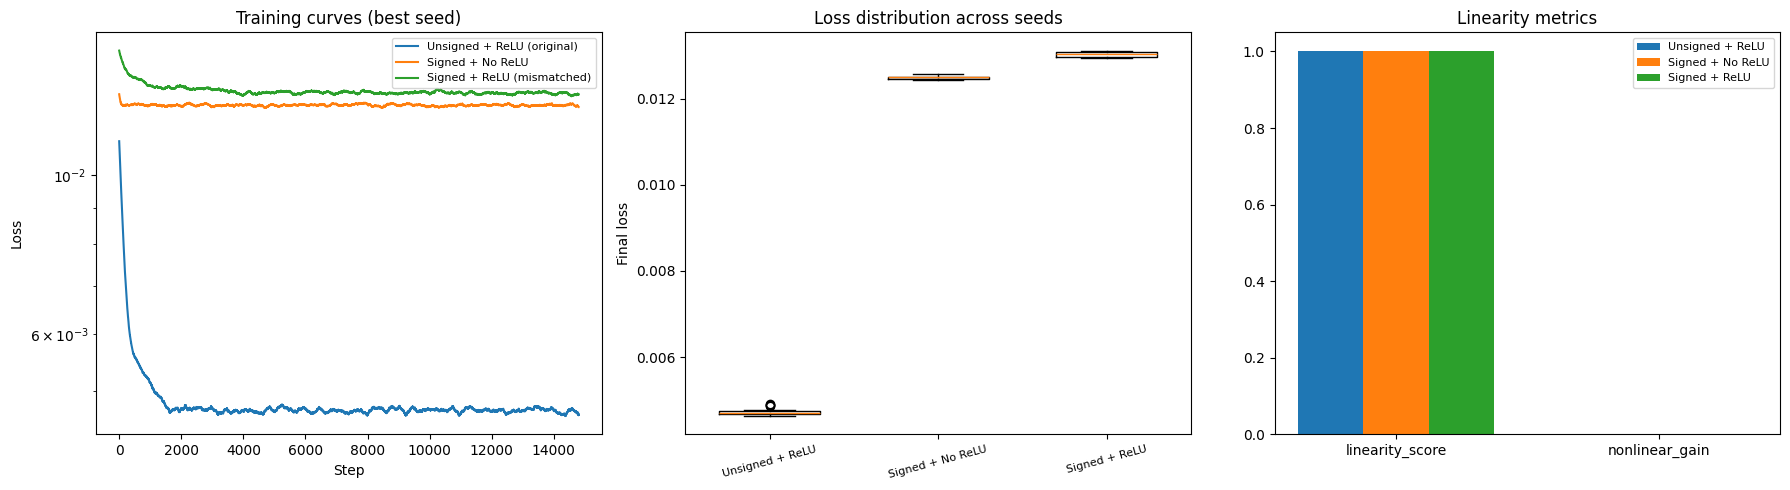

In [6]:
# Visualize training curves and compare
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
ax = axes[0]
for name, res in results_l1.items():
    smoothed = np.convolve(res['losses'], np.ones(200)/200, mode='valid')
    ax.plot(smoothed, label=name)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training curves (best seed)')
ax.legend(fontsize=8)
ax.set_yscale('log')

# Loss distribution across seeds
ax = axes[1]
positions = range(len(results_l1))
labels = []
for i, (name, res) in enumerate(results_l1.items()):
    short_name = name.split('(')[0].strip()
    labels.append(short_name)
    ax.boxplot(res['all_seed_losses'], positions=[i], widths=0.6)
ax.set_xticks(list(positions))
ax.set_xticklabels(labels, rotation=15, fontsize=8)
ax.set_ylabel('Final loss')
ax.set_title('Loss distribution across seeds')

# Feature geometry comparison
ax = axes[2]
metrics_names = ['linearity_score', 'nonlinear_gain']
x_pos = np.arange(len(metrics_names))
width = 0.25
for i, (name, res) in enumerate(results_l1.items()):
    vals = [res[m] for m in metrics_names]
    short_name = name.split('(')[0].strip()
    ax.bar(x_pos + i*width, vals, width, label=short_name)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(metrics_names)
ax.set_title('Linearity metrics')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Feature geometry: weight matrix visualization

Visualize the learned W matrix (encoder weights) for each config. For l=1 tied weights, this directly shows how features are embedded in the bottleneck.

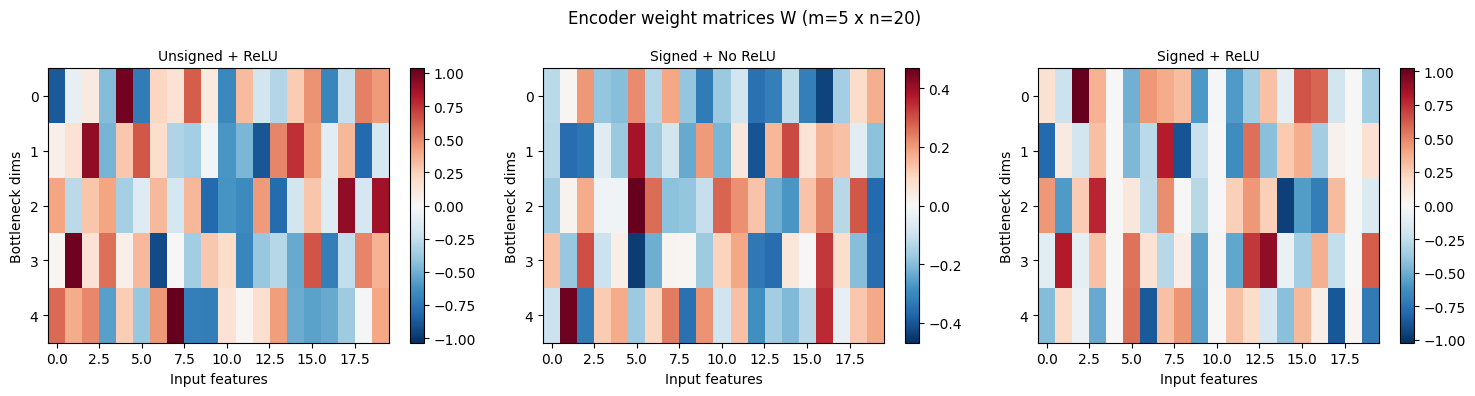

In [7]:
fig, axes = plt.subplots(1, len(results_l1), figsize=(5*len(results_l1), 4))

for i, (name, res) in enumerate(results_l1.items()):
    ax = axes[i]
    model = res['model']
    
    # Get encoder weight matrix
    W = None
    for pname, param in model.encoder.named_parameters():
        if 'weight' in pname:
            W = param.detach().cpu().numpy()
            break
    
    if W is not None:
        im = ax.imshow(W, aspect='auto', cmap='RdBu_r', vmin=-W.max(), vmax=W.max())
        ax.set_xlabel('Input features')
        ax.set_ylabel('Bottleneck dims')
        ax.set_title(name.split('(')[0].strip(), fontsize=10)
        plt.colorbar(im, ax=ax)

plt.suptitle(f'Encoder weight matrices W (m={m} x n={n})', fontsize=12)
plt.tight_layout()
plt.show()

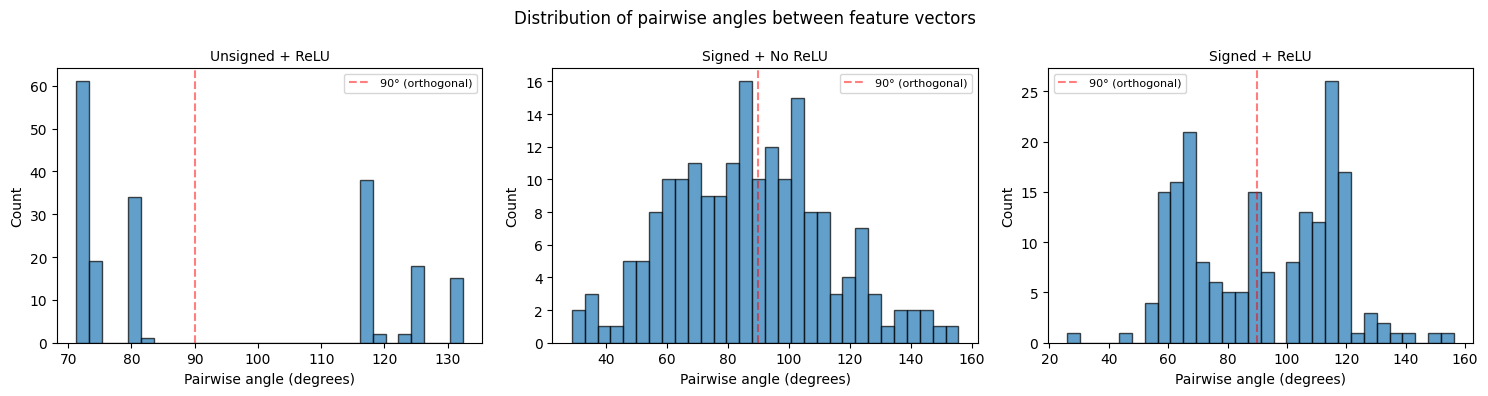

In [8]:
# Pairwise angle distributions
fig, axes = plt.subplots(1, len(results_l1), figsize=(5*len(results_l1), 4))

for i, (name, res) in enumerate(results_l1.items()):
    ax = axes[i]
    angles = res['angles']
    if angles:
        ax.hist(angles, bins=30, edgecolor='black', alpha=0.7)
        ax.axvline(90, color='red', linestyle='--', alpha=0.5, label='90° (orthogonal)')
        ax.set_xlabel('Pairwise angle (degrees)')
        ax.set_ylabel('Count')
        ax.set_title(name.split('(')[0].strip(), fontsize=10)
        ax.legend(fontsize=8)

plt.suptitle('Distribution of pairwise angles between feature vectors', fontsize=12)
plt.tight_layout()
plt.show()

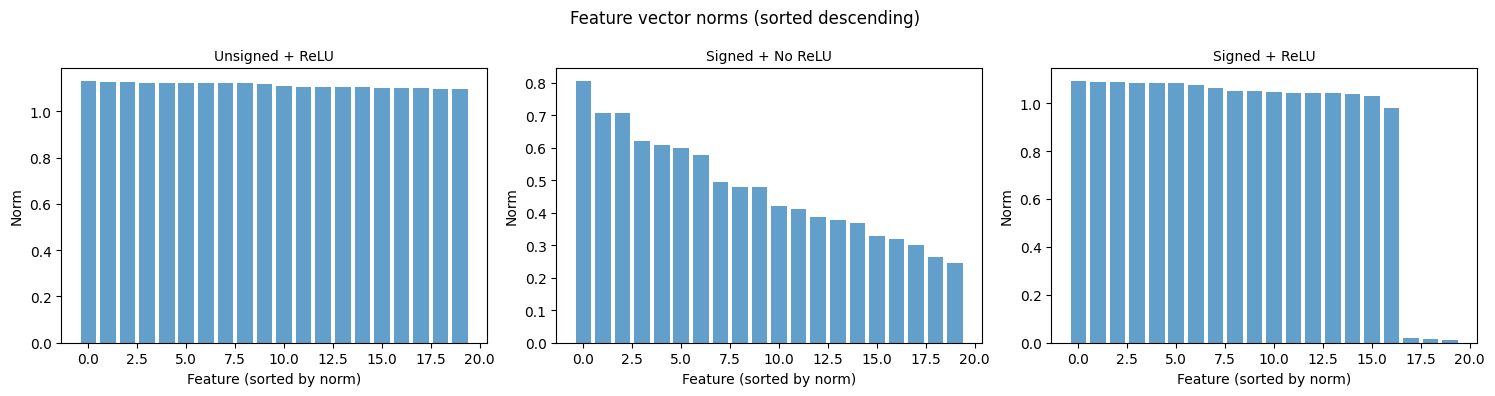

In [9]:
# Feature norms comparison
fig, axes = plt.subplots(1, len(results_l1), figsize=(5*len(results_l1), 4))

for i, (name, res) in enumerate(results_l1.items()):
    ax = axes[i]
    norms = res['norms']
    if norms:
        ax.bar(range(len(norms)), sorted(norms, reverse=True), alpha=0.7)
        ax.set_xlabel('Feature (sorted by norm)')
        ax.set_ylabel('Norm')
        ax.set_title(name.split('(')[0].strip(), fontsize=10)

plt.suptitle('Feature vector norms (sorted descending)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Antipodal pair analysis

A key prediction: with signed features, the model has **less need** for antipodal pairs because features can naturally take opposite signs. With unsigned features, antipodal pairs are a geometric trick to double capacity. Let's check if the angle distribution shifts.

In [10]:
def count_antipodal_pairs(model, threshold_degrees=10):
    """Count near-antipodal pairs (angle close to 180°)."""
    W = None
    for name, param in model.encoder.named_parameters():
        if 'weight' in name:
            W = param.detach().cpu().numpy()
            break
    if W is None:
        return 0, 0, []
    
    n_features = W.shape[1]
    antipodal_pairs = []
    
    for i in range(n_features):
        for j in range(i+1, n_features):
            v1, v2 = W[:, i], W[:, j]
            n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if n1 > 1e-6 and n2 > 1e-6:
                cos_angle = np.dot(v1, v2) / (n1 * n2)
                angle = np.arccos(np.clip(cos_angle, -1, 1)) * 180 / np.pi
                if angle > 180 - threshold_degrees:
                    antipodal_pairs.append((i, j, angle, n1, n2))
    
    total_pairs = n_features * (n_features - 1) // 2
    return len(antipodal_pairs), total_pairs, antipodal_pairs

print("Antipodal pair analysis (threshold: within 10° of 180°):")
print("="*60)
for name, res in results_l1.items():
    n_anti, n_total, pairs = count_antipodal_pairs(res['model'])
    print(f"\n{name}:")
    print(f"  {n_anti}/{n_total} pairs are near-antipodal ({100*n_anti/n_total:.1f}%)")
    if pairs:
        for i, j, angle, n1, n2 in pairs:
            print(f"  Features {i}-{j}: angle={angle:.1f}°, norms=({n1:.3f}, {n2:.3f})")

Antipodal pair analysis (threshold: within 10° of 180°):

Unsigned + ReLU (original):
  0/190 pairs are near-antipodal (0.0%)

Signed + No ReLU:
  0/190 pairs are near-antipodal (0.0%)

Signed + ReLU (mismatched):
  0/190 pairs are near-antipodal (0.0%)


## 7. Reconstruction quality: where do errors concentrate?

With signed features + ReLU decoder, the model literally cannot output negative values. Let's visualize per-feature reconstruction error and check if the mismatched config (signed + ReLU) systematically fails on negative values.

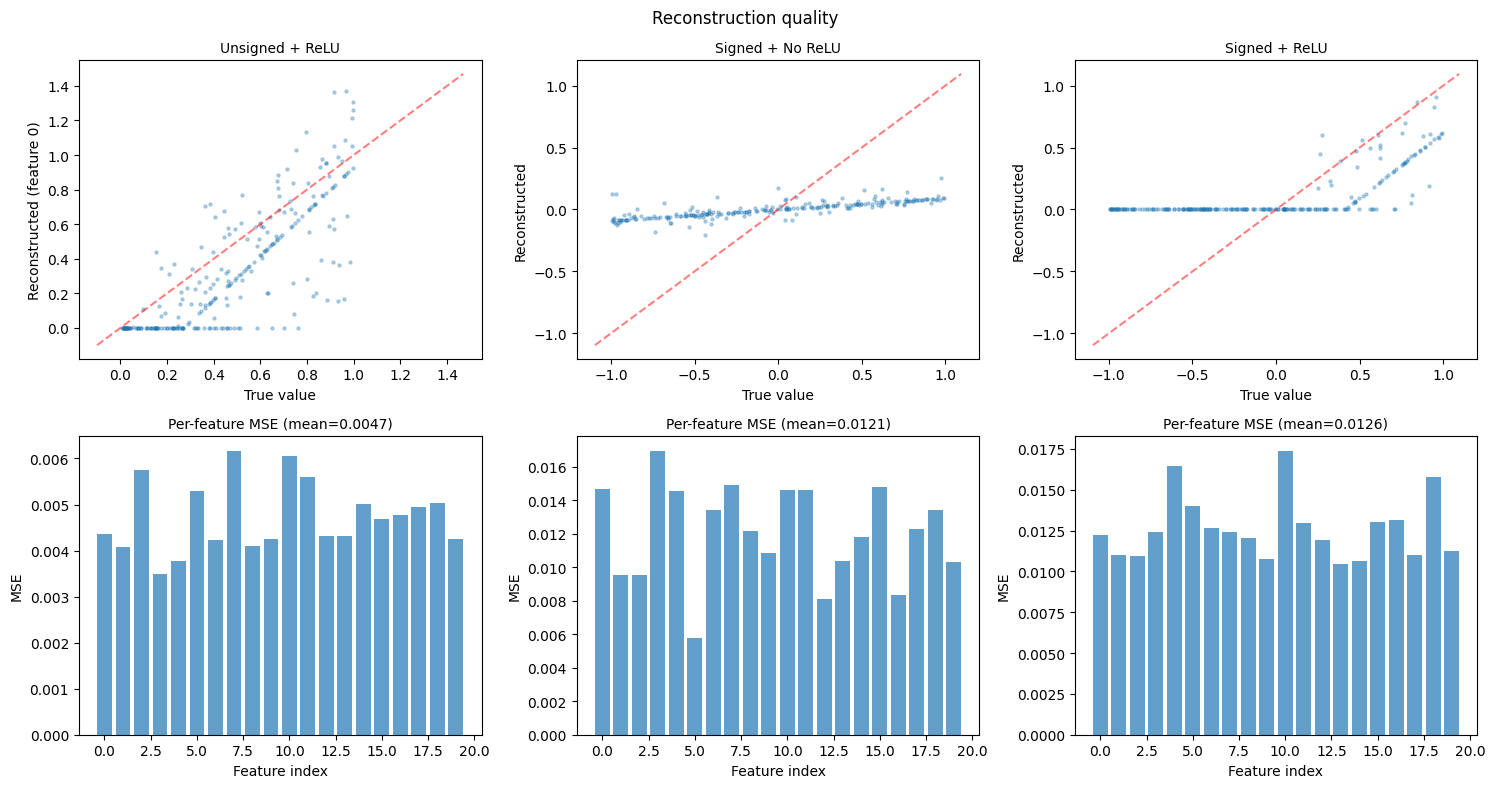

In [11]:
# Generate test data
n_test = 5000
x_test_signed = generate_signed_sparse_data(n_test, n, S)
x_test_unsigned = generate_sparse_data(n_test, n, S)

fig, axes = plt.subplots(2, len(results_l1), figsize=(5*len(results_l1), 8))

for i, (name, res) in enumerate(results_l1.items()):
    model = res['model']
    model.eval()
    signed = 'Signed' in name
    x_test = x_test_signed if signed else x_test_unsigned
    
    with torch.no_grad():
        x_recon, _ = model(x_test)
    
    # Scatter: true vs reconstructed for feature 0
    ax = axes[0, i]
    x_true = x_test[:, 0].cpu().numpy()
    x_rec = x_recon[:, 0].cpu().numpy()
    # Only plot active features for visibility
    active = x_true != 0
    ax.scatter(x_true[active], x_rec[active], alpha=0.3, s=5)
    lims = [min(x_true[active].min(), x_rec[active].min()) - 0.1,
            max(x_true[active].max(), x_rec[active].max()) + 0.1]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel('True value')
    ax.set_ylabel('Reconstructed')
    ax.set_title(name.split('(')[0].strip(), fontsize=10)
    
    # Per-feature MSE
    ax = axes[1, i]
    per_feature_mse = ((x_test - x_recon) ** 2).mean(dim=0).cpu().numpy()
    ax.bar(range(n), per_feature_mse, alpha=0.7)
    ax.set_xlabel('Feature index')
    ax.set_ylabel('MSE')
    ax.set_title(f'Per-feature MSE (mean={per_feature_mse.mean():.4f})', fontsize=10)

axes[0, 0].set_ylabel('Reconstructed (feature 0)')
plt.suptitle('Reconstruction quality', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Experiment 2: Deeper networks (l=2, l=3)

The key question from our project: does signed vs unsigned change the nonlinear gain at depth? With the positive homogeneity result (bias-free ReLU encoders are write-linear), we found that encoder depth doesn't help for unsigned features. Does this change for signed features?

In [12]:
# Compare l=1,2,3 for signed vs unsigned
n, m = 20, 5
S = 0.95
n_steps = 15000
n_seeds = 20

depth_configs = []
for l in [1, 2, 3]:
    depth_configs.append((f'Unsigned l={l}', False, Autoencoder, l))
    depth_configs.append((f'Signed l={l}', True, SignedAutoencoder, l))

results_depth = {}

for name, signed, ModelClass, l in depth_configs:
    print(f"\nRunning: {name}")
    
    best_loss = float('inf')
    best_model = None
    all_losses_seeds = []
    
    tw = (l == 1)  # tied weights only for l=1
    
    for seed in tqdm(range(n_seeds), desc='Seeds', leave=False):
        torch.manual_seed(seed)
        model = ModelClass(n, m, l=l, tied_weights=tw).to(device)
        losses = train_signed_autoencoder(
            model, n_steps=n_steps, S=S, signed=signed, verbose=False
        )
        final_loss = np.mean(losses[-200:])
        all_losses_seeds.append(final_loss)
        
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
            best_losses = losses
    
    metrics = measure_signed_linearity(best_model, S=S, signed=signed)
    geom = compute_feature_geometry(best_model)
    
    results_depth[name] = {
        'model': best_model, 'losses': best_losses,
        'final_loss': best_loss, 'all_seed_losses': all_losses_seeds,
        'l': l, 'signed': signed,
        **metrics, **geom,
    }
    
    print(f"  loss={best_loss:.6f}, linearity={metrics['linearity_score']:.4f}, "
          f"nonlinear_gain={metrics['nonlinear_gain']:.4f}")


Running: Unsigned l=1


Seeds:   0%|          | 0/20 [00:00<?, ?it/s]

Seeds:   5%|▌         | 1/20 [00:03<00:57,  3.01s/it]

Seeds:  10%|█         | 2/20 [00:06<01:03,  3.54s/it]

Seeds:  15%|█▌        | 3/20 [00:13<01:25,  5.01s/it]

...

Seeds:  85%|████████▌ | 17/20 [02:50<00:30, 10.09s/it]

Seeds:  90%|█████████ | 18/20 [02:59<00:19,  9.88s/it]

Seeds:  95%|█████████▌| 19/20 [03:08<00:09,  9.66s/it]

Seeds: 100%|██████████| 20/20 [03:18<00:00,  9.63s/it]

  loss=0.006465, linearity=0.8329, nonlinear_gain=0.5270


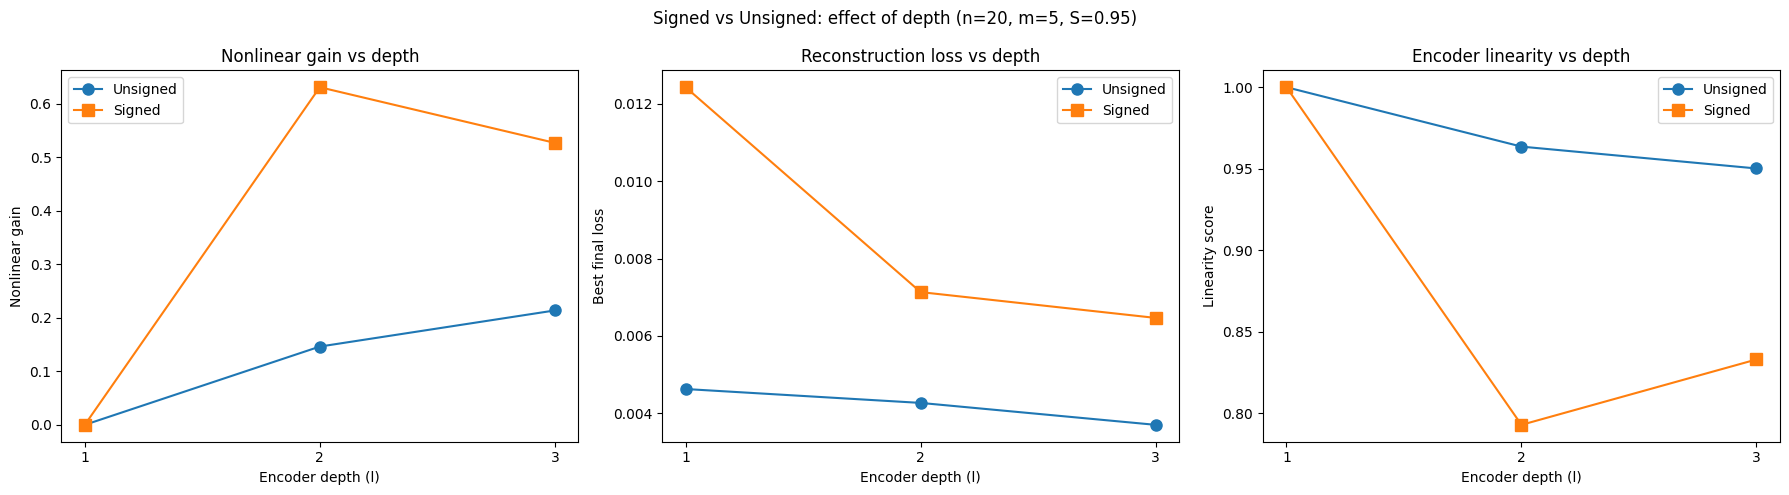

In [13]:
# Plot: nonlinear gain vs depth, signed vs unsigned
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ls = [1, 2, 3]

# Nonlinear gain
ax = axes[0]
unsigned_gains = [results_depth[f'Unsigned l={l}']['nonlinear_gain'] for l in ls]
signed_gains = [results_depth[f'Signed l={l}']['nonlinear_gain'] for l in ls]
ax.plot(ls, unsigned_gains, 'o-', label='Unsigned', markersize=8)
ax.plot(ls, signed_gains, 's-', label='Signed', markersize=8)
ax.set_xlabel('Encoder depth (l)')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Nonlinear gain vs depth')
ax.legend()
ax.set_xticks(ls)

# Final loss
ax = axes[1]
unsigned_losses = [results_depth[f'Unsigned l={l}']['final_loss'] for l in ls]
signed_losses = [results_depth[f'Signed l={l}']['final_loss'] for l in ls]
ax.plot(ls, unsigned_losses, 'o-', label='Unsigned', markersize=8)
ax.plot(ls, signed_losses, 's-', label='Signed', markersize=8)
ax.set_xlabel('Encoder depth (l)')
ax.set_ylabel('Best final loss')
ax.set_title('Reconstruction loss vs depth')
ax.legend()
ax.set_xticks(ls)

# Linearity score
ax = axes[2]
unsigned_lin = [results_depth[f'Unsigned l={l}']['linearity_score'] for l in ls]
signed_lin = [results_depth[f'Signed l={l}']['linearity_score'] for l in ls]
ax.plot(ls, unsigned_lin, 'o-', label='Unsigned', markersize=8)
ax.plot(ls, signed_lin, 's-', label='Signed', markersize=8)
ax.set_xlabel('Encoder depth (l)')
ax.set_ylabel('Linearity score')
ax.set_title('Encoder linearity vs depth')
ax.legend()
ax.set_xticks(ls)

plt.suptitle(f'Signed vs Unsigned: effect of depth (n={n}, m={m}, S={S})', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Experiment 3: Sweep over compression ratio

How does the signed/unsigned distinction interact with the compression ratio n/m? At low compression, both should be easy. At high compression, signed features have higher information content per active feature (1 bit of sign info) — does this change the superposition structure?

In [14]:
n = 20
m_values = [2, 5, 8, 10, 15, 18]
S = 0.95
n_steps = 15000
n_seeds = 15
l = 1  # Focus on l=1 first

sweep_results = {'unsigned': {}, 'signed': {}}

for m in m_values:
    for sign_type, signed, ModelClass in [('unsigned', False, Autoencoder), ('signed', True, SignedAutoencoder)]:
        print(f"m={m}, {sign_type}...")
        
        best_loss = float('inf')
        best_model = None
        
        for seed in range(n_seeds):
            torch.manual_seed(seed)
            model = ModelClass(n, m, l=l).to(device)
            losses = train_signed_autoencoder(
                model, n_steps=n_steps, S=S, signed=signed, verbose=False
            )
            final_loss = np.mean(losses[-200:])
            if final_loss < best_loss:
                best_loss = final_loss
                best_model = model
        
        metrics = measure_signed_linearity(best_model, S=S, signed=signed)
        geom = compute_feature_geometry(best_model)
        
        sweep_results[sign_type][m] = {
            'model': best_model, 'final_loss': best_loss,
            **metrics, **geom,
        }

print("Done!")

m=2, unsigned...


m=2, signed...


m=5, unsigned...


m=5, signed...


m=8, unsigned...


...

m=15, unsigned...


m=15, signed...


m=18, unsigned...


m=18, signed...


Done!


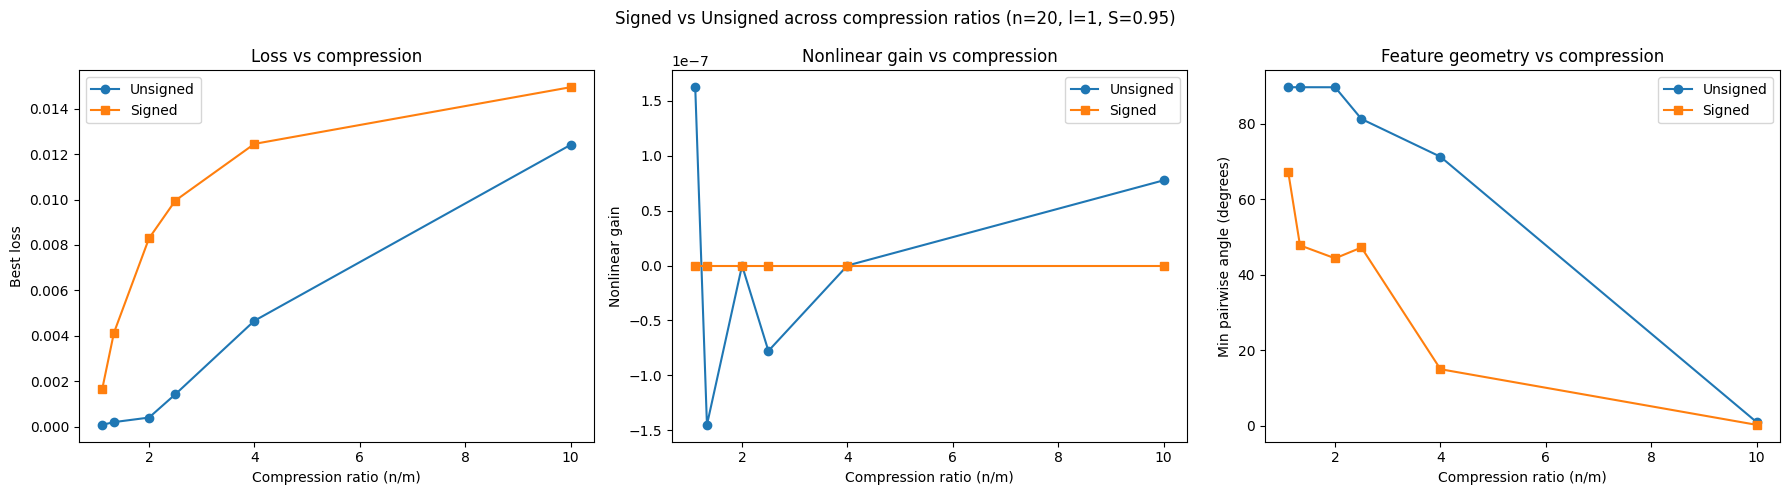

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ratios = [n/m for m in m_values]

# Loss vs compression
ax = axes[0]
ax.plot(ratios, [sweep_results['unsigned'][m]['final_loss'] for m in m_values], 'o-', label='Unsigned')
ax.plot(ratios, [sweep_results['signed'][m]['final_loss'] for m in m_values], 's-', label='Signed')
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Best loss')
ax.set_title('Loss vs compression')
ax.legend()

# Nonlinear gain vs compression
ax = axes[1]
ax.plot(ratios, [sweep_results['unsigned'][m]['nonlinear_gain'] for m in m_values], 'o-', label='Unsigned')
ax.plot(ratios, [sweep_results['signed'][m]['nonlinear_gain'] for m in m_values], 's-', label='Signed')
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Nonlinear gain vs compression')
ax.legend()

# Min angle vs compression
ax = axes[2]
ax.plot(ratios, [sweep_results['unsigned'][m]['min_angle'] for m in m_values], 'o-', label='Unsigned')
ax.plot(ratios, [sweep_results['signed'][m]['min_angle'] for m in m_values], 's-', label='Signed')
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Min pairwise angle (degrees)')
ax.set_title('Feature geometry vs compression')
ax.legend()

plt.suptitle(f'Signed vs Unsigned across compression ratios (n={n}, l={l}, S={S})', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Positive homogeneity with signed features

For unsigned features, we showed that bias-free ReLU encoders satisfy f(t*x) = t*f(x) for t > 0. But for signed features, we also care about t < 0. Does f(-x) = -f(x)? ReLU breaks this: ReLU(-a) ≠ -ReLU(a). This means **the positive homogeneity argument is asymmetric** — it holds for scaling up but not for sign flips.

This could be exactly where signed features break the "encoder is always linear" result.

In [16]:
# Test: how does the encoder respond to sign flips?
# For unsigned model and signed model at l=2

for name in ['Unsigned l=2', 'Signed l=2']:
    if name not in results_depth:
        continue
    model = results_depth[name]['model']
    model.eval()
    signed = 'Signed' in name
    
    # Generate test points
    gen_fn = generate_signed_sparse_data if signed else generate_sparse_data
    x_test = gen_fn(500, n, S)
    
    with torch.no_grad():
        z_pos = model.encode(x_test)
        z_neg = model.encode(-x_test)  # sign-flipped input
        z_scaled = model.encode(2 * x_test)  # scaled input
    
    # Check f(2x) vs 2*f(x) — positive homogeneity
    homo_error = ((z_scaled - 2 * z_pos) ** 2).mean().item()
    
    # Check f(-x) vs -f(x) — odd symmetry
    odd_error = ((z_neg + z_pos) ** 2).mean().item()
    
    # Baseline: how big are the encodings?
    z_scale = (z_pos ** 2).mean().item()
    
    print(f"\n{name}:")
    print(f"  Positive homogeneity error: {homo_error:.6f} (relative: {homo_error/z_scale:.6f})")
    print(f"  Odd symmetry error:         {odd_error:.6f} (relative: {odd_error/z_scale:.6f})")
    print(f"  (Encoding scale: {z_scale:.6f})")
    
    if homo_error / z_scale < 1e-4:
        print(f"  → Positive homogeneity holds (as expected for bias-free ReLU)")
    if odd_error / z_scale < 1e-4:
        print(f"  → Odd symmetry holds (surprising!)")
    elif odd_error / z_scale > 0.1:
        print(f"  → Odd symmetry BROKEN — ReLU treats positive and negative inputs differently")
        print(f"    This is where signed features create fundamentally different behavior!")


Unsigned l=2:
  Positive homogeneity error: 0.038537 (relative: 0.171227)
  Odd symmetry error:         0.537735 (relative: 2.389258)
  (Encoding scale: 0.225064)
  → Odd symmetry BROKEN — ReLU treats positive and negative inputs differently
    This is where signed features create fundamentally different behavior!

Signed l=2:
  Positive homogeneity error: 0.057762 (relative: 0.064220)
  Odd symmetry error:         1.034869 (relative: 1.150561)
  (Encoding scale: 0.899447)
  → Odd symmetry BROKEN — ReLU treats positive and negative inputs differently
    This is where signed features create fundamentally different behavior!


## 11. Feature trajectory visualization

For a single feature direction e_i, trace how the encoder maps t*e_i for t in [-2, 2]. With unsigned features and positive homogeneity, these are straight lines through the origin (for t > 0). With signed features, the trajectory may bend at t=0 due to ReLU.

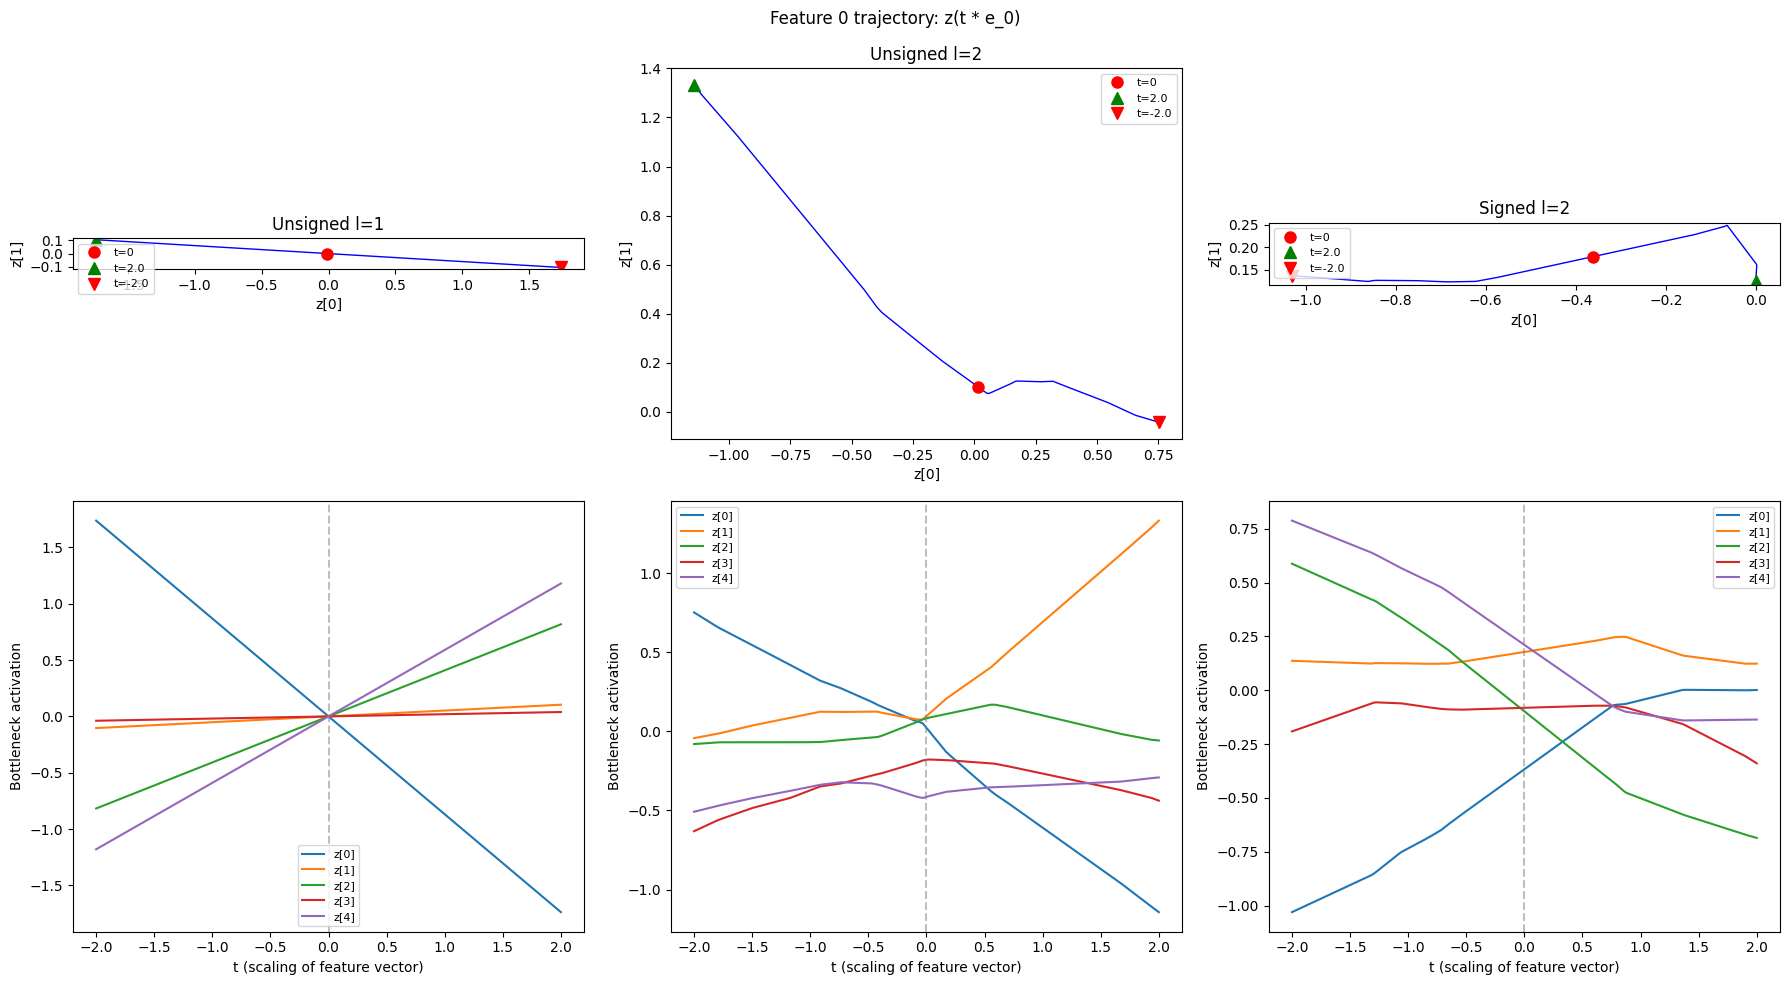

In [17]:
# Pick a feature and trace its encoding trajectory
feature_idx = 0
t_values = np.linspace(-2, 2, 200)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, name in enumerate(['Unsigned l=1', 'Unsigned l=2', 'Signed l=2']):
    if name not in results_depth:
        continue
    model = results_depth[name]['model']
    model.eval()
    
    # Create unit vector for feature_idx
    e_i = torch.zeros(1, n, device=device)
    e_i[0, feature_idx] = 1.0
    
    trajectories = []
    with torch.no_grad():
        for t in t_values:
            z = model.encode(t * e_i)
            trajectories.append(z[0].cpu().numpy())
    trajectories = np.array(trajectories)
    
    # Plot first 2 bottleneck dimensions
    ax = axes[0, col]
    ax.plot(trajectories[:, 0], trajectories[:, 1], 'b-', linewidth=1)
    # Mark t=0
    mid = len(t_values) // 2
    ax.plot(trajectories[mid, 0], trajectories[mid, 1], 'ro', markersize=8, label='t=0')
    # Mark positive and negative ends
    ax.plot(trajectories[-1, 0], trajectories[-1, 1], 'g^', markersize=8, label=f't={t_values[-1]}')
    ax.plot(trajectories[0, 0], trajectories[0, 1], 'rv', markersize=8, label=f't={t_values[0]}')
    ax.set_xlabel('z[0]')
    ax.set_ylabel('z[1]')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_aspect('equal')
    
    # Plot all bottleneck dims vs t
    ax = axes[1, col]
    for d in range(min(model.m, 5)):
        ax.plot(t_values, trajectories[:, d], label=f'z[{d}]')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('t (scaling of feature vector)')
    ax.set_ylabel('Bottleneck activation')
    ax.legend(fontsize=8)

plt.suptitle(f'Feature {feature_idx} trajectory: z(t * e_{feature_idx})', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Experiment 4: Importance weighting with signed features

The Toy Models paper uses importance weighting I_i = 0.7^i. With signed features, does the importance-driven feature selection change? Features that carry sign info have higher information content.

In [18]:
n, m = 20, 5
S = 0.95
n_steps = 15000
n_seeds = 20
importance = get_feature_importance(n, decay=0.7, device=device)

importance_configs = [
    ('Unsigned + importance', False, Autoencoder),
    ('Signed + importance', True, SignedAutoencoder),
]

results_importance = {}

for name, signed, ModelClass in importance_configs:
    print(f"\nRunning: {name}")
    best_loss = float('inf')
    best_model = None
    
    for seed in tqdm(range(n_seeds), desc='Seeds'):
        torch.manual_seed(seed)
        model = ModelClass(n, m, l=1).to(device)
        losses = train_signed_autoencoder(
            model, n_steps=n_steps, S=S, signed=signed,
            importance=importance, verbose=False
        )
        final_loss = np.mean(losses[-200:])
        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model
    
    geom = compute_feature_geometry(best_model)
    results_importance[name] = {'model': best_model, 'final_loss': best_loss, **geom}
    print(f"  loss={best_loss:.6f}, min_norm={geom['min_norm']:.3f}, min_angle={geom['min_angle']:.1f}°")


Running: Unsigned + importance


Seeds:   0%|          | 0/20 [00:00<?, ?it/s]

Seeds:   5%|▌         | 1/20 [00:04<01:20,  4.22s/it]

Seeds:  10%|█         | 2/20 [00:08<01:11,  3.97s/it]

Seeds:  15%|█▌        | 3/20 [00:12<01:08,  4.04s/it]

...

Seeds:  90%|█████████ | 18/20 [01:06<00:07,  3.60s/it]

Seeds:  95%|█████████▌| 19/20 [01:10<00:03,  3.67s/it]

Seeds: 100%|██████████| 20/20 [01:14<00:00,  3.73s/it]

Seeds: 100%|██████████| 20/20 [01:14<00:00,  3.72s/it]

  loss=0.000460, min_norm=0.001, min_angle=22.1°


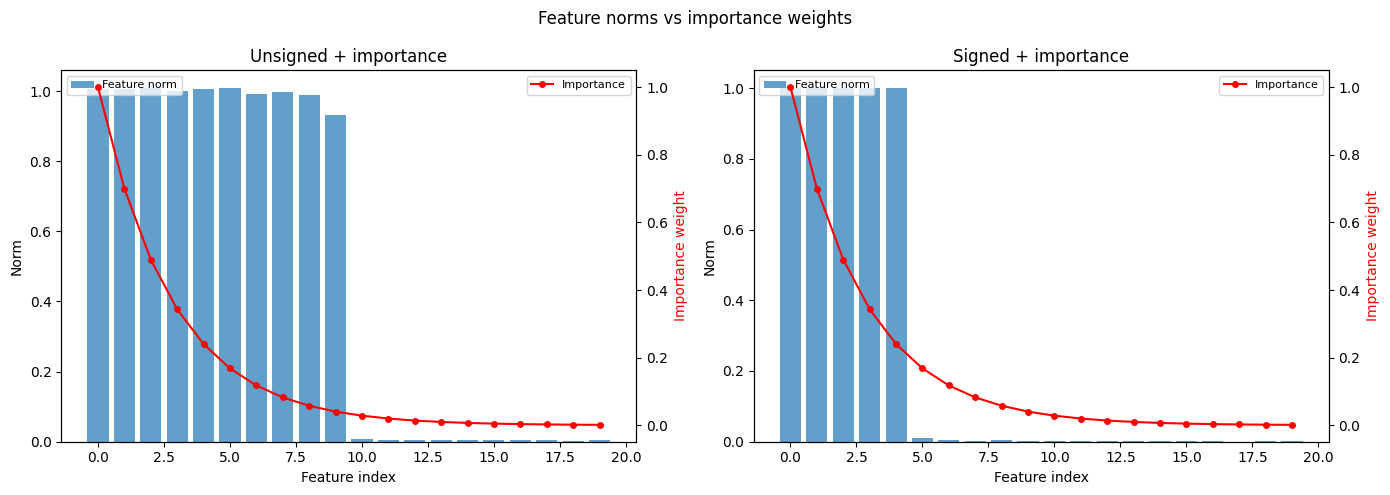

In [19]:
# Compare feature norms with importance weighting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, res) in enumerate(results_importance.items()):
    ax = axes[i]
    norms = res['norms']
    imp_vals = importance.cpu().numpy()
    
    ax.bar(range(len(norms)), norms, alpha=0.7, label='Feature norm')
    ax2 = ax.twinx()
    ax2.plot(range(len(imp_vals)), imp_vals, 'r-o', markersize=4, label='Importance')
    ax2.set_ylabel('Importance weight', color='r')
    
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Norm')
    ax.set_title(name)
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Feature norms vs importance weights', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Summary table

In [20]:
import pandas as pd

# Compile all results into a summary table
rows = []

for name, res in results_l1.items():
    rows.append({
        'Experiment': 'l=1 comparison',
        'Config': name,
        'Loss': f"{res['final_loss']:.6f}",
        'Linearity': f"{res['linearity_score']:.4f}",
        'NL Gain': f"{res['nonlinear_gain']:.4f}",
        'Min Norm': f"{res['min_norm']:.3f}",
        'Min Angle': f"{res['min_angle']:.1f}°",
    })

for name, res in results_depth.items():
    rows.append({
        'Experiment': 'Depth sweep',
        'Config': name,
        'Loss': f"{res['final_loss']:.6f}",
        'Linearity': f"{res['linearity_score']:.4f}",
        'NL Gain': f"{res['nonlinear_gain']:.4f}",
        'Min Norm': f"{res['min_norm']:.3f}",
        'Min Angle': f"{res['min_angle']:.1f}°",
    })

df = pd.DataFrame(rows)
display(df)

,Experiment,Config,Loss,Linearity,NL Gain,Min Norm,Min Angle
0,l=1 comparison,Unsigned + ReLU (original),0.004628,1.0000,-0.0000,1.095,71.3°
1,l=1 comparison,Signed + No ReLU,0.012428,1.0000,0.0000,0.246,28.9°
2,l=1 comparison,Signed + ReLU (mismatched),0.012938,1.0000,0.0000,0.013,26.1°
3,Depth sweep,Unsigned l=1,0.004628,1.0000,-0.0000,1.095,71.3°
4,Depth sweep,Signed l=1,0.012428,1.0000,0.0000,0.246,28.9°
5,Depth sweep,Unsigned l=2,0.004269,0.9635,0.1463,0.023,53.1°
6,Depth sweep,Signed l=2,0.007132,0.7928,0.6310,0.555,35.8°
7,Depth sweep,Unsigned l=3,0.003702,0.9501,0.2138,0.025,58.4°
8,Depth sweep,Signed l=3,0.006465,0.8329,0.5270,0.504,6.0°


## 14. Discussion and next steps

### Theoretical predictions before looking at results:

1. **Signed + ReLU decoder should fail badly**: The ReLU clamps all output to ≥0, so it literally cannot reconstruct negative feature values. This should show up as high loss and systematic errors on negative values.

2. **Signed features break positive homogeneity for sign flips**: While f(t·x) = t·f(x) for t > 0 still holds for bias-free ReLU, f(-x) ≠ -f(x). This means the encoder's behavior at negative inputs is genuinely nonlinear, potentially opening the door for deeper encoders to help.

3. **Antipodal pairs may be less useful with signed features**: In the unsigned case, antipodal pairs let the model distinguish features by sign of the dot product, then use ReLU to zero out the wrong one. With signed features, both signs of the dot product carry information, so antipodal geometry may not work as cleanly.

4. **Information content per feature is higher with signs**: Each active signed feature carries ~1 extra bit (the sign), so the effective information rate at a given sparsity is higher. This could shift the phase boundary for when superposition becomes necessary.

### Key questions to answer from the results:
- Does the nonlinear gain increase for signed features at depth l≥2?
- Does the feature geometry (angle distribution) qualitatively change?
- At what compression ratio does signed vs unsigned diverge most?